In [ ]:
#had to download preprocessor and helper libraries
pip install preprocessor
pip install helper

In [98]:
#Import necessary libraries

import pandas as pd
import numpy as np
import datetime as dt
from datetime import datetime, timedelta
from datetime import date

import statistics as stat #statistics library
from scipy import stats as scstats #statistics within library
import matplotlib.pyplot as plt #Library for charting data, most common
import seaborn as sns #Library for extra datasets, charting data
import plotly as plot #Library for interactive charts 
import plotly.express as px

import streamlit as st
import preprocessor,helper
import plotly.figure_factory as ff

In [2]:
#import the athlete information Data Frame
df = pd.read_csv('athlete_events.csv')

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
#Shows information on the Athlete DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [4]:
#Shows shape and description of Athletes DF

print('Shape: \n',df.shape)
print('\n')
print('Description: \n', df.describe())

Shape: 
 (271116, 15)


Description: 
                   ID            Age         Height         Weight  \
count  271116.000000  261642.000000  210945.000000  208241.000000   
mean    68248.954396      25.556898     175.338970      70.702393   
std     39022.286345       6.393561      10.518462      14.348020   
min         1.000000      10.000000     127.000000      25.000000   
25%     34643.000000      21.000000     168.000000      60.000000   
50%     68205.000000      24.000000     175.000000      70.000000   
75%    102097.250000      28.000000     183.000000      79.000000   
max    135571.000000      97.000000     226.000000     214.000000   

                Year  
count  271116.000000  
mean     1978.378480  
std        29.877632  
min      1896.000000  
25%      1960.000000  
50%      1988.000000  
75%      2002.000000  
max      2016.000000  


### Top 5 Rows



,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


### Bottom 5 Rows



,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


### Information



...

### Unique Values



ID        135571
Name      134732
Sex            2
Age           74
Height        95
Weight       220
Team        1184
NOC          230
Games         51
Year          35
Season         2
City          42
Sport         66
Event        765
Medal          3
dtype: int64

### Descriptive Statistics



,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


,index,0
0,ID,135571
1,Name,134732
2,Sex,2
3,Age,74
4,Height,95
5,Weight,220
6,Team,1184
7,NOC,230
8,Games,51
9,Year,35


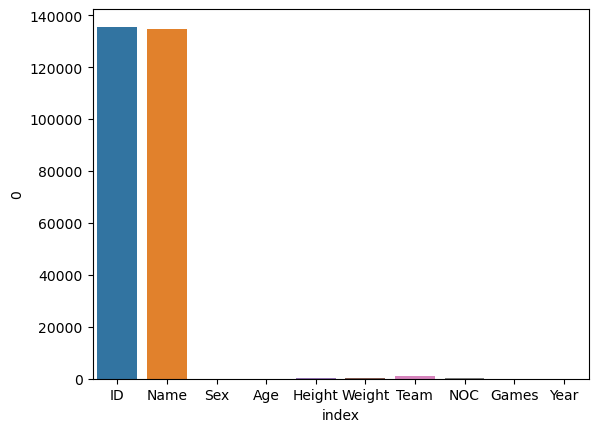

In [5]:
#uses my data quality check to gain information on the data
import dataquality as dq
dq.data_check(df)

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   269731 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB


In [6]:
#looks at the duplicates
duplicates = df[df.duplicated()]
print(duplicates)

            ID                                 Name Sex   Age  Height  Weight  \
1252       704                   Dsir Antoine Acket   M  27.0     NaN     NaN   
4282      2449               William Truman Aldrich   M  48.0     NaN     NaN   
4283      2449               William Truman Aldrich   M  48.0     NaN     NaN   
4862      2777               Hermann Reinhard Alker   M  43.0     NaN     NaN   
4864      2777               Hermann Reinhard Alker   M  43.0     NaN     NaN   
...        ...                                  ...  ..   ...     ...     ...   
269994  135072  Anna Katrina Zinkeisen (-Heseltine)   F  46.0     NaN     NaN   
269995  135072  Anna Katrina Zinkeisen (-Heseltine)   F  46.0     NaN     NaN   
269997  135072  Anna Katrina Zinkeisen (-Heseltine)   F  46.0     NaN     NaN   
269999  135073   Doris Clare Zinkeisen (-Johnstone)   F  49.0     NaN     NaN   
270200  135173                     Henri Achille Zo   M  58.0     NaN     NaN   

                 Team  NOC 

In [7]:
#drops duplicates, shows no duplicates remain
df = df.drop_duplicates(keep = 'last')
df.duplicated().sum()

0

In [8]:
#Fills missing Medal with "None"
df['Medal'] = df['Medal'].fillna('None')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None


In [9]:
#displays basic statistics
print('Basic Statistics:\n', df.describe(include = 'all'))

Basic Statistics:
                    ID                      Name     Sex            Age  \
count   269731.000000                    269731  269731  260416.000000   
unique            NaN                    134732       2            NaN   
top               NaN  Heikki Ilmari Savolainen       M            NaN   
freq              NaN                        39  195353            NaN   
mean     68264.949591                       NaN     NaN      25.454776   
std      39026.253843                       NaN     NaN       6.163869   
min          1.000000                       NaN     NaN      10.000000   
25%      34655.500000                       NaN     NaN      21.000000   
50%      68233.000000                       NaN     NaN      24.000000   
75%     102111.000000                       NaN     NaN      28.000000   
max     135571.000000                       NaN     NaN      97.000000   

               Height         Weight           Team     NOC        Games  \
count   210917.0

In [10]:
#shows ages of participants above the age of 70
above_75 = df[df['Age'] >75]
above_75

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
9371,5146,George Denholm Armour,M,84.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
56601,28993,Albin Dbrich,M,76.0,NaN,NaN,Austria,AUT,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Sculpturing, Unknown Event",None
60863,31173,Thomas Cowperthwait Eakins,M,88.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
62839,32215,George Alfred Elcock,M,76.0,NaN,NaN,Great Britain,GBR,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
98118,49663,Winslow Homer,M,96.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
133534,67219,Sir John Lavery,M,76.0,NaN,NaN,Great Britain,GBR,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
138814,69729,Max Liebermann,M,80.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Graphic Arts",None
154855,77710,Robert Tait McKenzie,M,81.0,NaN,NaN,Canada,CAN,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Sculpturing, Unknown Event",None
170798,85838,William Newzam Prior Nicholson,M,76.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",None
170994,85936,Charles Henry Niehaus,M,77.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Sculpturing, Unknown Event",None


In [11]:
#shows how many participants are above the age of 70
above_75.count()

ID        12
Name      12
Sex       12
Age       12
Height     0
Weight     0
Team      12
NOC       12
Games     12
Year      12
Season    12
City      12
Sport     12
Event     12
Medal     12
dtype: int64

In [12]:
#shows the athletes below the age of 15
below_12 = df[df['Age'] < 12]
below_12

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
43468,22411,Magdalena Cecilia Colledge,F,11.0,152.0,NaN,Great Britain,GBR,1932 Winter,1932,Winter,Lake Placid,Figure Skating,Figure Skating Women's Singles,None
73461,37333,Carlos Bienvenido Front Barrera,M,11.0,NaN,NaN,Spain,ESP,1992 Summer,1992,Summer,Barcelona,Rowing,Rowing Men's Coxed Eights,None
79024,40129,Luigina Giavotti,F,11.0,NaN,NaN,Italy,ITA,1928 Summer,1928,Summer,Amsterdam,Gymnastics,Gymnastics Women's Team All-Around,Silver
94058,47618,"Sonja Henie (-Topping, -Gardiner, -Onstad)",F,11.0,155.0,45.0,Norway,NOR,1924 Winter,1924,Winter,Chamonix,Figure Skating,Figure Skating Women's Singles,None
101378,51268,Beatrice Hutiu,F,11.0,151.0,38.0,Romania,ROU,1968 Winter,1968,Winter,Grenoble,Figure Skating,Figure Skating Women's Singles,None
102916,52070,Etsuko Inada,F,11.0,NaN,NaN,Japan,JPN,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Figure Skating,Figure Skating Women's Singles,None
140650,70616,Liu Luyang,F,11.0,NaN,NaN,China,CHN,1988 Winter,1988,Winter,Calgary,Figure Skating,Figure Skating Mixed Ice Dancing,None
142882,71691,Dimitrios Loundras,M,10.0,NaN,NaN,Ethnikos Gymnastikos Syllogos,GRE,1896 Summer,1896,Summer,Athina,Gymnastics,"Gymnastics Men's Parallel Bars, Teams",Bronze
152798,76675,Marcelle Matthews,F,11.0,NaN,NaN,South Africa,RSA,1960 Winter,1960,Winter,Squaw Valley,Figure Skating,Figure Skating Mixed Pairs,None
237141,118925,Megan Olwen Devenish Taylor (-Mandeville-Ellis),F,11.0,157.0,NaN,Great Britain,GBR,1932 Winter,1932,Winter,Lake Placid,Figure Skating,Figure Skating Women's Singles,None


In [13]:
#shows the count of athletes below the ages of 15
below_12.count()

ID        14
Name      14
Sex       14
Age       14
Height     8
Weight     6
Team      14
NOC       14
Games     14
Year      14
Season    14
City      14
Sport     14
Event     14
Medal     14
dtype: int64

In [14]:
#Imports the NOC Regions DF

dfn = pd.read_csv('noc_regions.csv')

dfn.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [15]:
#Shows information on NOC Regions DF
dfn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     230 non-null    object
 1   region  227 non-null    object
 2   notes   21 non-null     object
dtypes: object(3)
memory usage: 5.5+ KB


### Top 5 Rows



,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


### Bottom 5 Rows



,NOC,region,notes
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN
229,ZIM,Zimbabwe,NaN


### Information



...

### Unique Values



NOC       230
region    206
notes      21
dtype: int64

### Descriptive Statistics



,NOC,region,notes
count,230,227,21
unique,230,206,21
top,AFG,Germany,Netherlands Antilles
freq,1,4,1


,index,0
0,NOC,230
1,region,206
2,notes,21


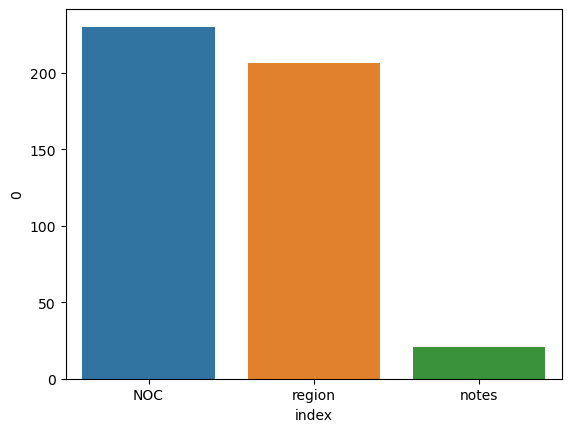

In [16]:
import dataquality as dq
dq.data_check(dfn)

In [17]:
#displays basic statistics
print('Basic Statistics:\n', dfn.describe(include = 'all'))

Basic Statistics:
         NOC   region                 notes
count   230      227                    21
unique  230      206                    21
top     AFG  Germany  Netherlands Antilles
freq      1        4                     1


In [18]:
#dfn.rename(columns={'NOC':'Country_Code'}, inplace=True)
#dfn.head()

In [19]:
#filtering only summer Olympics
df_sum = df[df['Season'] == 'Summer']

#merge with region_df
df_sum = df_sum.merge(dfn, on = 'NOC', how = 'left')

#dropping duplicates
df_sum.drop_duplicates(inplace = True)

df_sum.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,None,Netherlands,NaN


In [20]:
df_sum

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,None,Netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221162,135565,Fernando scar Zylberberg,M,27.0,168.0,76.0,Argentina,ARG,2004 Summer,2004,Summer,Athina,Hockey,Hockey Men's Hockey,None,Argentina,NaN
221163,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,None,USA,NaN
221164,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,None,Russia,NaN
221165,135567,Aleksandr Viktorovich Zyuzin,M,28.0,183.0,72.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Rowing,Rowing Men's Lightweight Coxless Fours,None,Russia,NaN


### Medal Tally

In [73]:
#function to get medal count by country and year
def get_medal_count():
    #user input for year and country
    year = int(input('Enter the year: '))
    country = input('Enter the country (ex. USA, CAN): ').upper()

    #filters data for the given year and country
    filtered_data = df_sum[(df_sum['Year'] == year) & (df_sum['NOC'] == country)]

    #counts medal by type
    medal_count = filtered_data['Medal'].value_counts()

    #print results
    print(f"\nMedal count for {country} in {year}:")
    print(f"Gold: {medal_count.get('Gold', 0)}")
    print(f"Silver: {medal_count.get('Silver', 0)}")
    print(f"Bronze: {medal_count.get('Bronze', 0)}")
    print(f"Total: {len(filtered_data[filtered_data['Medal'] != 'None'])}")

get_medal_count()

Enter the year:  2016 
Enter the country (ex. USA, CAN):  usa



Medal count for USA in 2016:
Gold: 139
Silver: 54
Bronze: 71
Total: 264


In [219]:
df_sum.to_csv('athlete_olympic.csv', index=False)

In [75]:
#function to create the medal tally chart
def create_medal_tally():
    #filter relevant columns
    rel_data = df_sum[df_sum['Medal'] != 'None']

    #group data by year, NOC, medal type, and count the medals
    medal_tally = rel_data.groupby(['Year', 'NOC', 'Medal']).size().unstack(fill_value = 0)
    
    #renaming columns
    medal_tally.rename(columns={'Gold': 'Gold_Medals', 'Silver': 'Silver_Medals', 'Bronze': 'Bronze_Medals'}, inplace = True)
    
    #adding a Total column
    medal_tally['Total_Medals'] = medal_tally.sum(axis=1)
    
    #reset the index
    medal_tally.reset_index(inplace = True)
    
    return medal_tally

#function to get medal tally for specific country
def get_cntry_medal_tally(medal_tally):
    #get user input for country
    country = input('Enter the country (ex. USA, CAN): ').upper()
    
    #filters medal tally for the chosen country
    cntry_medal_tally = medal_tally[medal_tally['NOC'] == country]
    
    #check to see if there is data for that country
    if cntry_medal_tally.empty:
        print(f"No data found for the country code: {country}")
    else:
        #display the medal tally for the country
        print(f"\nMedal Tally for {country}")
        print(cntry_medal_tally)

#create the medal tally chart
medal_tally = create_medal_tally()

#allow the user to choose a country and display its medal tally
get_cntry_medal_tally(medal_tally)

Enter the country (ex. USA, CAN):  usa



Medal Tally for USA
Medal  Year  NOC  Bronze_Medals  Gold_Medals  Silver_Medals  Total_Medals
9      1896  USA              2           11              7            20
33     1900  USA             17           30             16            63
45     1904  USA            125          128            141           394
63     1906  USA              6           12              6            24
82     1908  USA             15           34             16            65
101    1912  USA             36           46             25           107
123    1920  USA             38          111             45           194
153    1924  USA             49           97             36           182
187    1928  USA             17           47             24            88
216    1932  USA             61           81             47           189
247    1936  USA             16           51             29            96
285    1948  USA             35           87             30           152
327    1952  USA 

### Overall Analysis

In [77]:
#shows an overall analysis of the data

#finds unique stats about the olympic games
editions = df_sum['Year'].unique().shape[0]-1
cities = df_sum['City'].unique().shape[0]
sports = df_sum['Sport'].unique().shape[0]
events = df_sum['Event'].unique().shape[0]
athletes = df_sum['Name'].unique().shape[0]
nations = df_sum['region'].unique().shape[0]

#shows the stats
print(f"Total Editions: {editions}")
print(f"Total Host Cities: {cities}")
print(f"Total Sports: {sports}")
print(f"Total Events: {events}")
print(f"Total Athletes: {athletes}")
print(f"Total Nations: {nations}")

Total Editions: 28
Total Host Cities: 23
Total Sports: 52
Total Events: 651
Total Athletes: 116122
Total Nations: 206


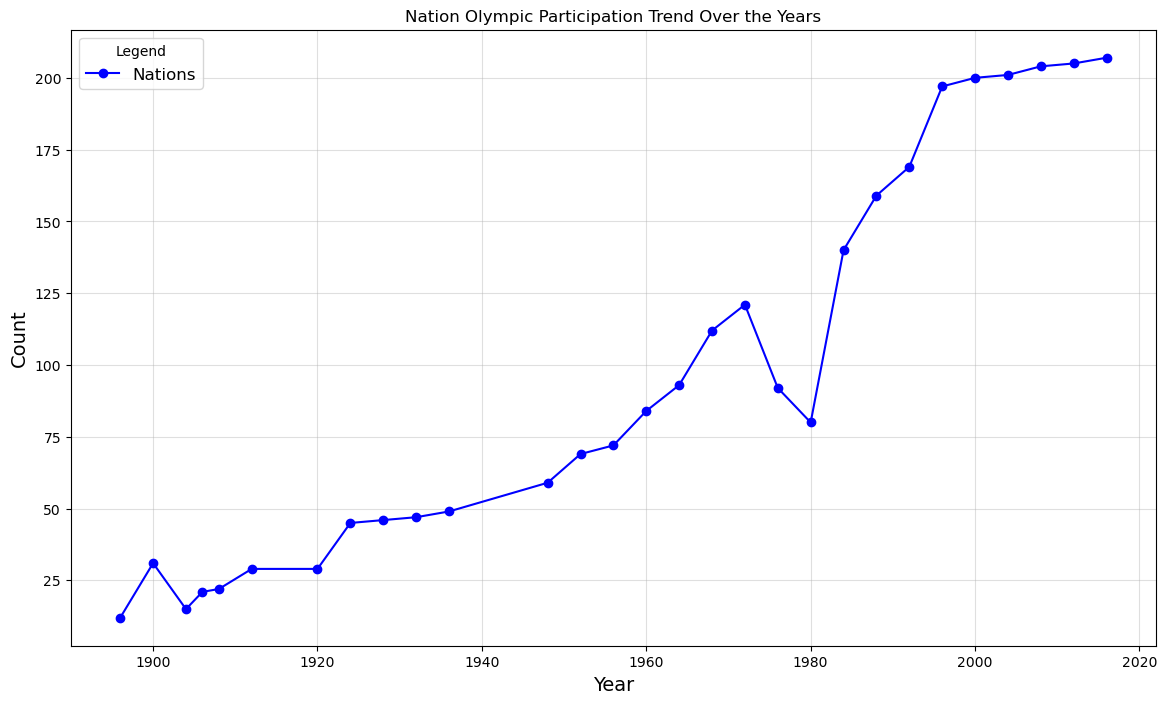

In [118]:
#Nations Per Year Line Plot

#data preparation
#counts unique nations per year
nations_p_yr = df_sum.groupby('Year')['NOC'].nunique()

#plots the line plots
plt.figure(figsize=(14,8))

#Nations plot
plt.plot(nations_p_yr.index, nations_p_yr.values, label='Nations', color = 'blue', marker = 'o')

#Add labels, title, and legend
plt.title('Nation Olympic Participation Trend Over the Years')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Legend', fontsize=12)
plt.grid(alpha=0.4)

#show the plot
plt.show()

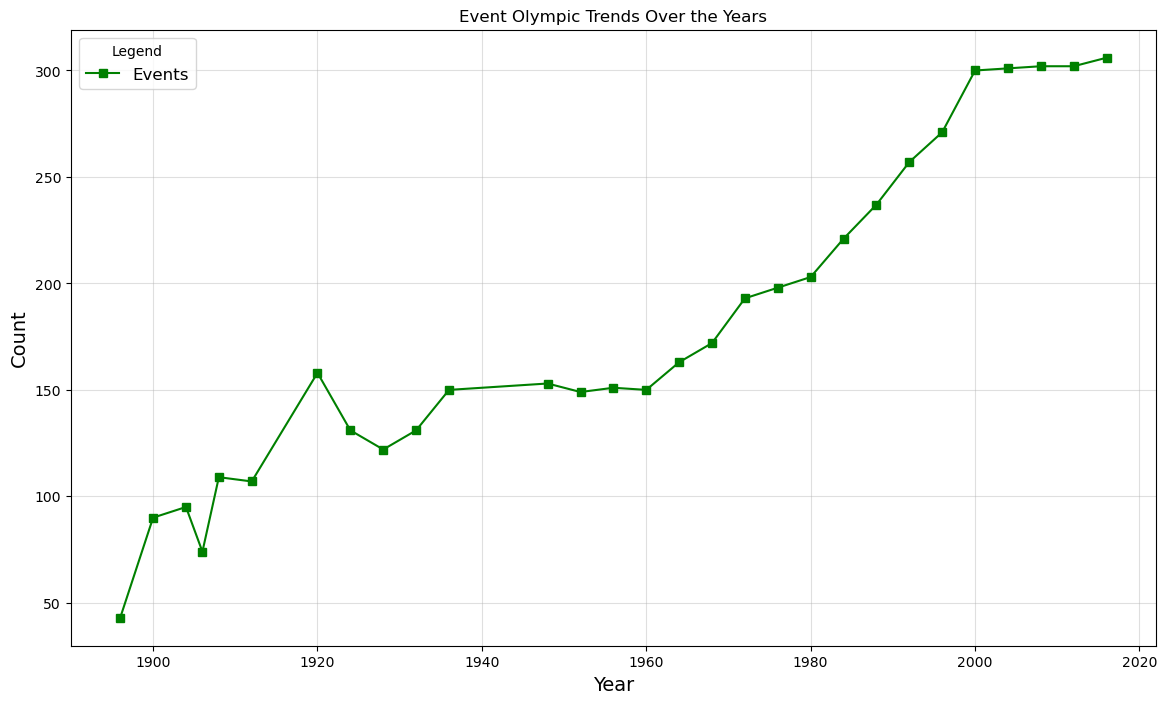

In [120]:
#Events Per Year Line Plot

#Data Preparation
#counts unique events per year
events_p_yr = df_sum.groupby('Year')['Event'].nunique()

#plots the line plots
plt.figure(figsize=(14,8))

#Events plot
plt.plot(events_p_yr.index, events_p_yr.values, label='Events', color = 'green', marker = 's')

#Add labels, title, and legend
plt.title('Event Olympic Trends Over the Years')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Legend', fontsize=12)
plt.grid(alpha=0.4)

#show the plot
plt.show()

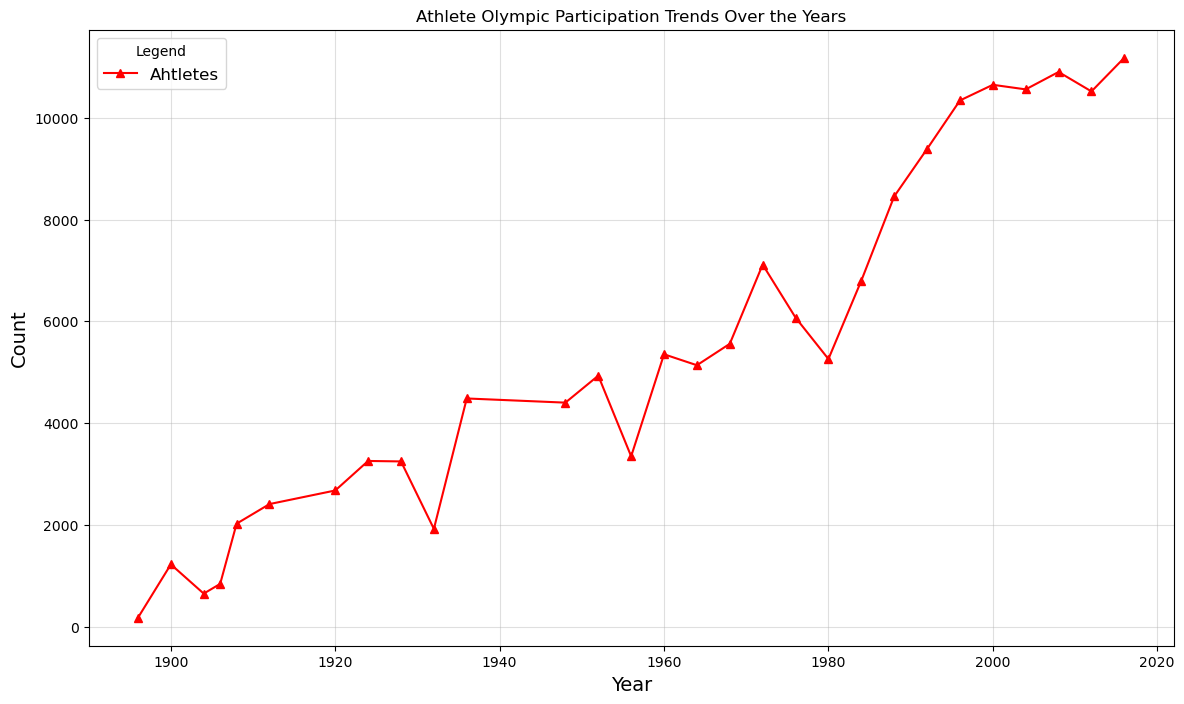

In [122]:
#Athletes Per Year Line Plot

#remove duplicates for accurate counting
df_unique = df_sum.drop_duplicates(subset = ['Year', 'ID'])

#counts unique athletes per year
athletes_p_yr = df_sum.groupby('Year')['ID'].nunique()

#plots the line plots
plt.figure(figsize=(14,8))

#Athletes plot
plt.plot(athletes_p_yr.index, athletes_p_yr.values, label='Ahtletes', color = 'red', marker = '^')

#Add labels, title, and legend
plt.title('Athlete Olympic Participation Trends Over the Years')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Legend', fontsize=12)
plt.grid(alpha=0.4)

#show the plot
plt.show()

2025-01-20 15:33:07.473 
  command:

    streamlit run /opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

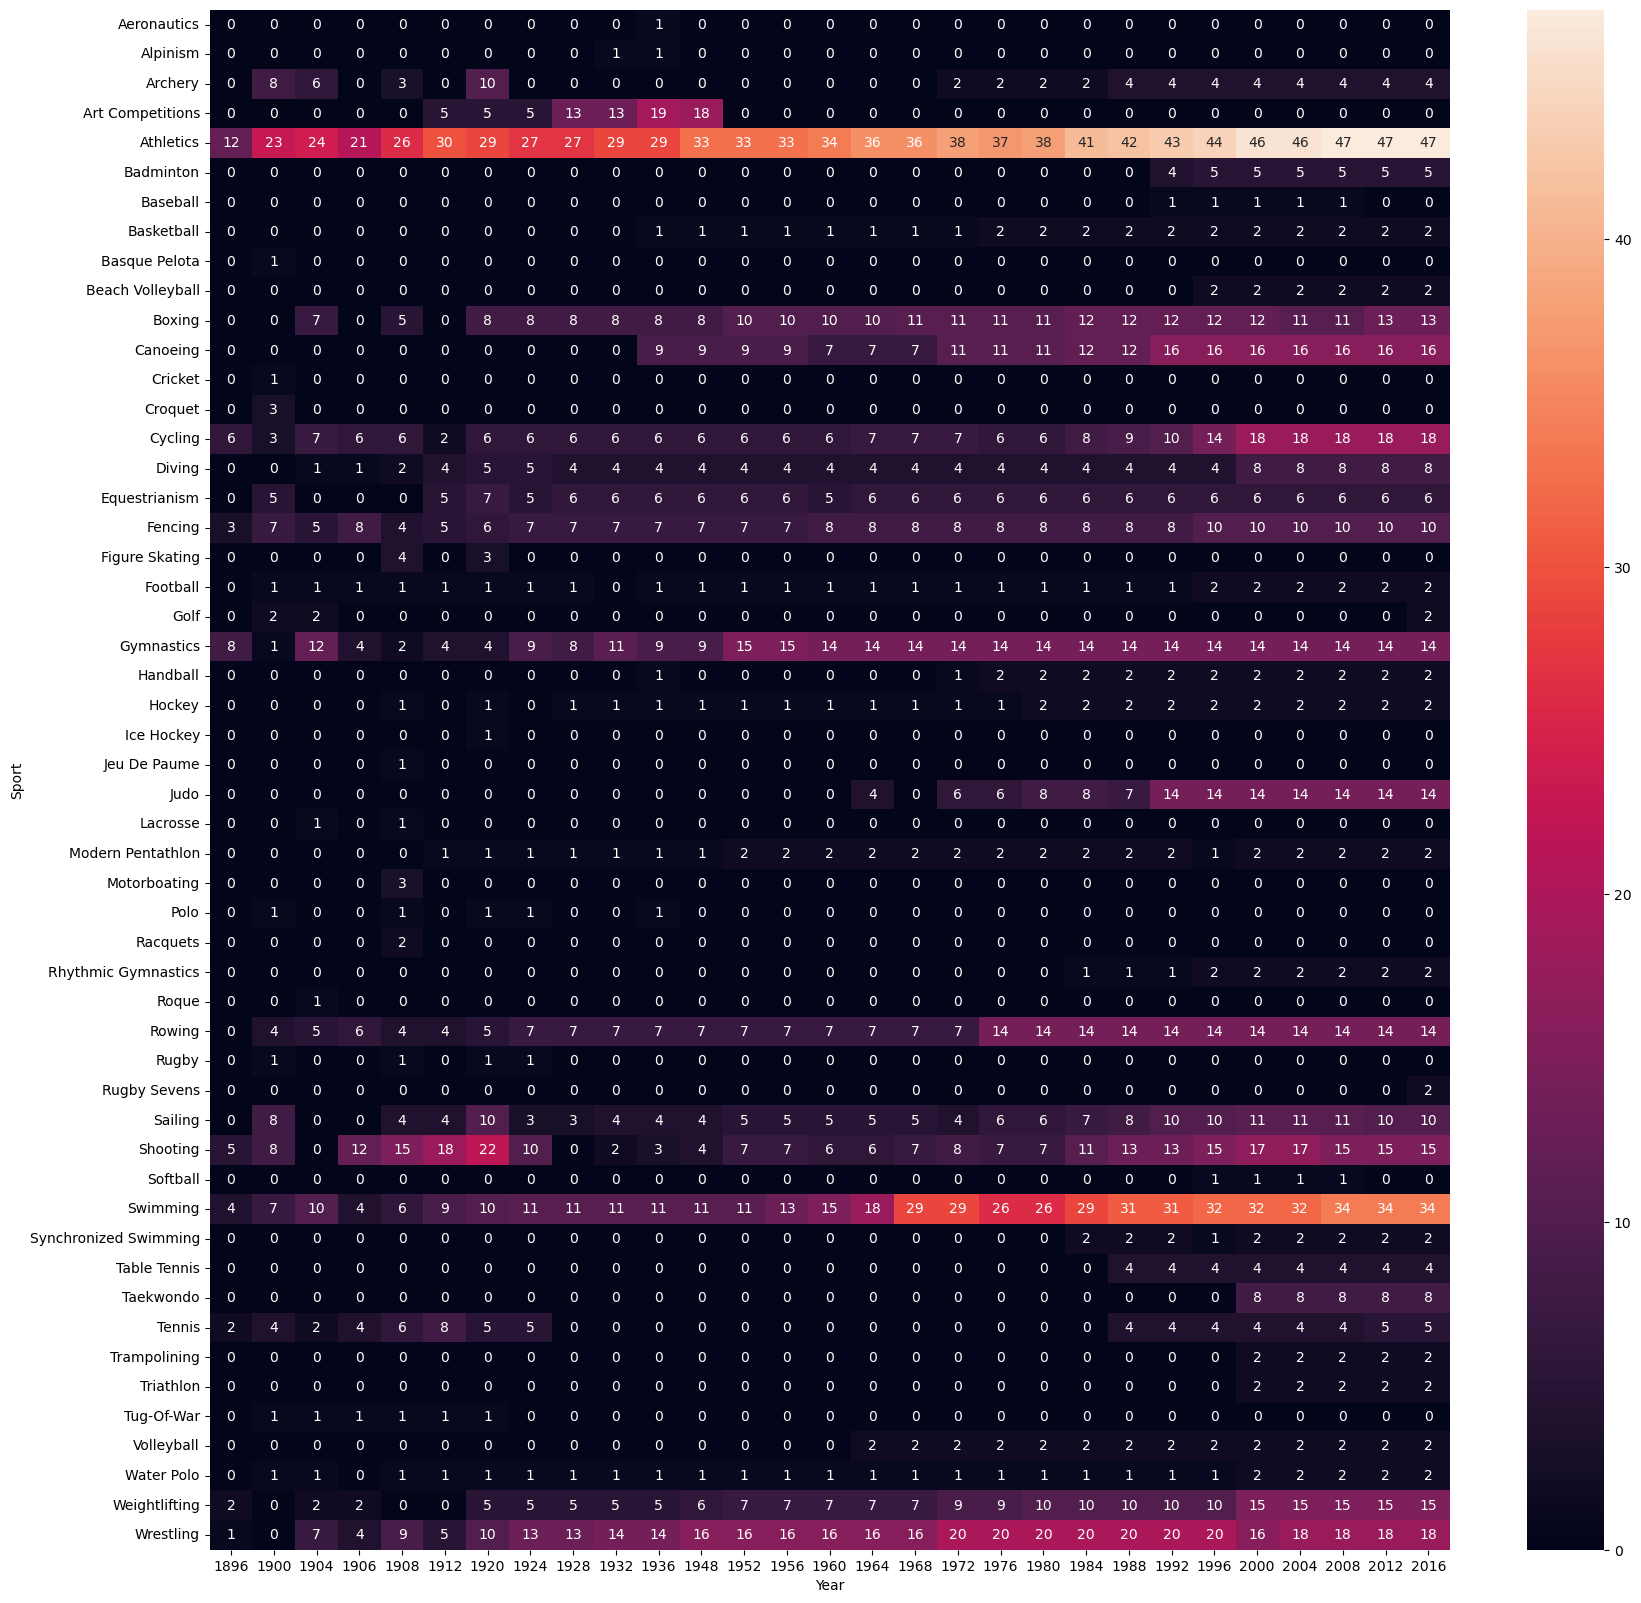

In [124]:
#Heatmap for number of events for each sport/event

st.title('Number of Events over Time(Every Sport)')
fig, ax = plt.subplots(figsize = (20,20))
x = df_sum.drop_duplicates(['Year', 'Sport', 'Event'])
ax = sns.heatmap(x.pivot_table(index='Sport', columns='Year', values='Event', 
                               aggfunc='count').fillna(0).astype('int'), annot=True)
st.pyplot(fig)

In [139]:
#Top 15 most successful athletes of all time

#Filters rows with non-null medal values (includes only rows where there is a medal won)
medal_data = df_sum[df_sum['Medal'] != 'None']

#Groups by athlete and calculates total medals won (by category)
ath_medal=(
    medal_data.groupby(['Name', 'Sport', 'NOC'])
    .agg(
        Golds=('Medal', lambda x: (x == 'Gold').sum()),
        Silvers=('Medal', lambda x: (x == 'Silver').sum()),
        Bronzes=('Medal', lambda x: (x == 'Bronze').sum()),
        Total=('Medal', 'count')
    )
    .sort_values(by='Total', ascending=False)
)

#Resets the index
ath_medal.reset_index(inplace=True)

#selects the top 15 athletes
top_15_ath = ath_medal.head(15)

#Displays the results
print('Top 15 Most Successful Athletes of All Time')
top_15_ath

Top 15 Most Successful Athletes of All Time


,Name,Sport,NOC,Golds,Silvers,Bronzes,Total
0,"Michael Fred Phelps, II",Swimming,USA,23,3,2,28
1,Larysa Semenivna Latynina (Diriy-),Gymnastics,URS,9,5,4,18
2,Nikolay Yefimovich Andrianov,Gymnastics,URS,7,5,3,15
3,Borys Anfiyanovych Shakhlin,Gymnastics,URS,7,4,2,13
4,Takashi Ono,Gymnastics,JPN,5,4,4,13
5,Edoardo Mangiarotti,Fencing,ITA,6,5,2,13
6,Sawao Kato,Gymnastics,JPN,8,3,1,12
7,Natalie Anne Coughlin (-Hall),Swimming,USA,3,4,5,12
8,Aleksey Yuryevich Nemov,Gymnastics,RUS,4,2,6,12
9,Ryan Steven Lochte,Swimming,USA,6,3,3,12


### Country Analysis

Enter the 3-letter NOC code for the country of choice (ex. USA, CAN):  usa


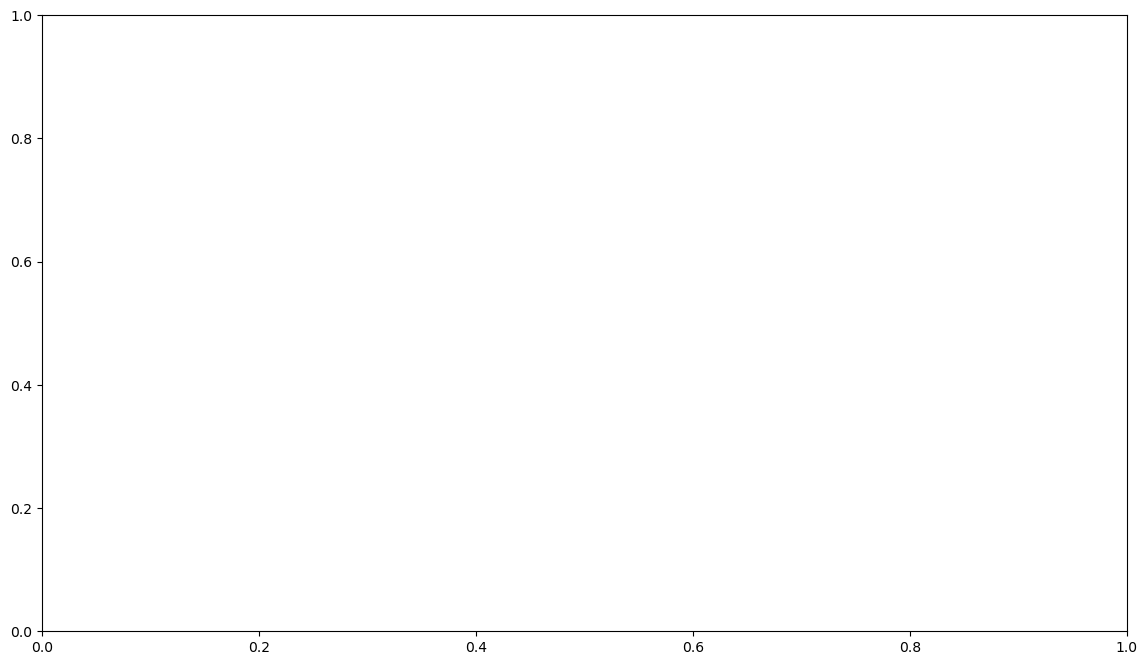

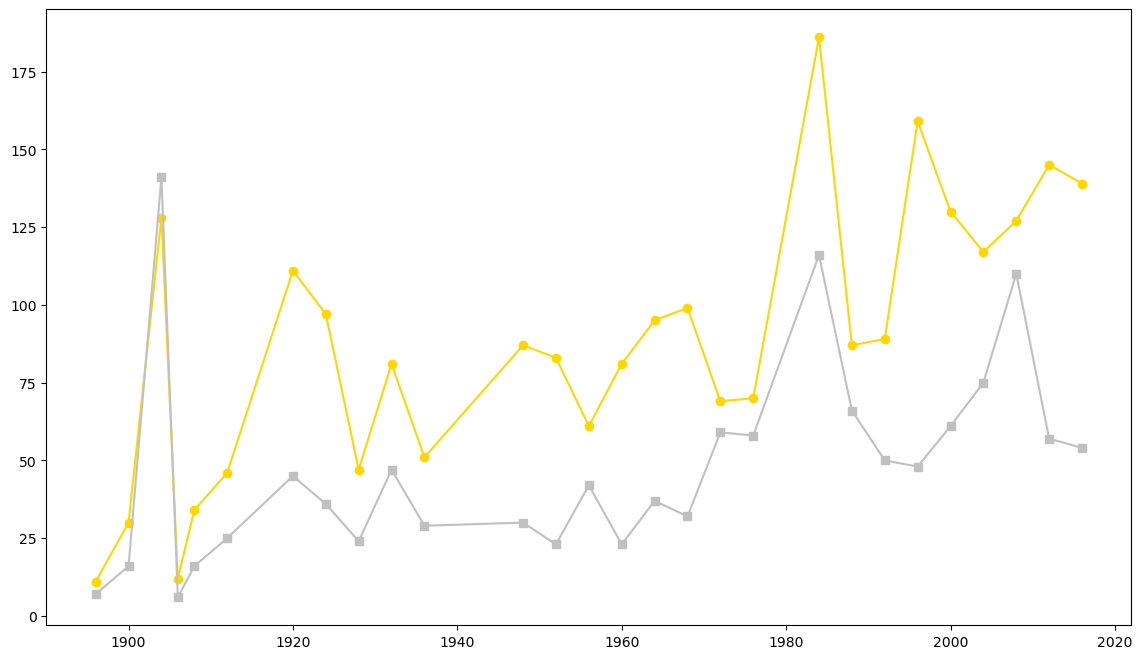

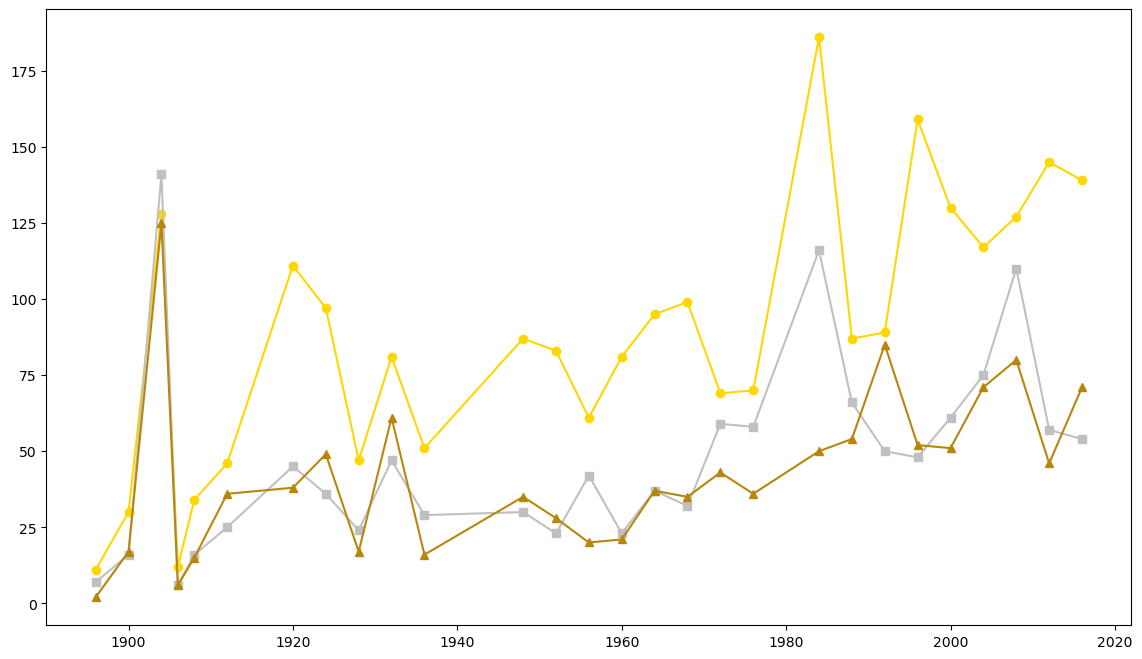

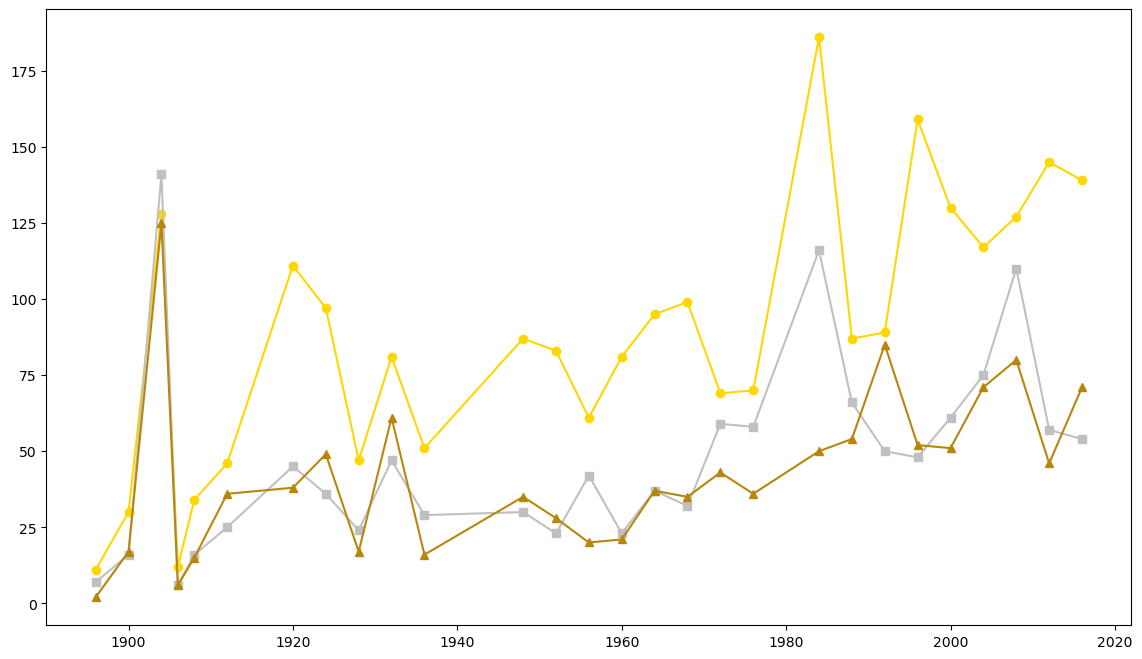

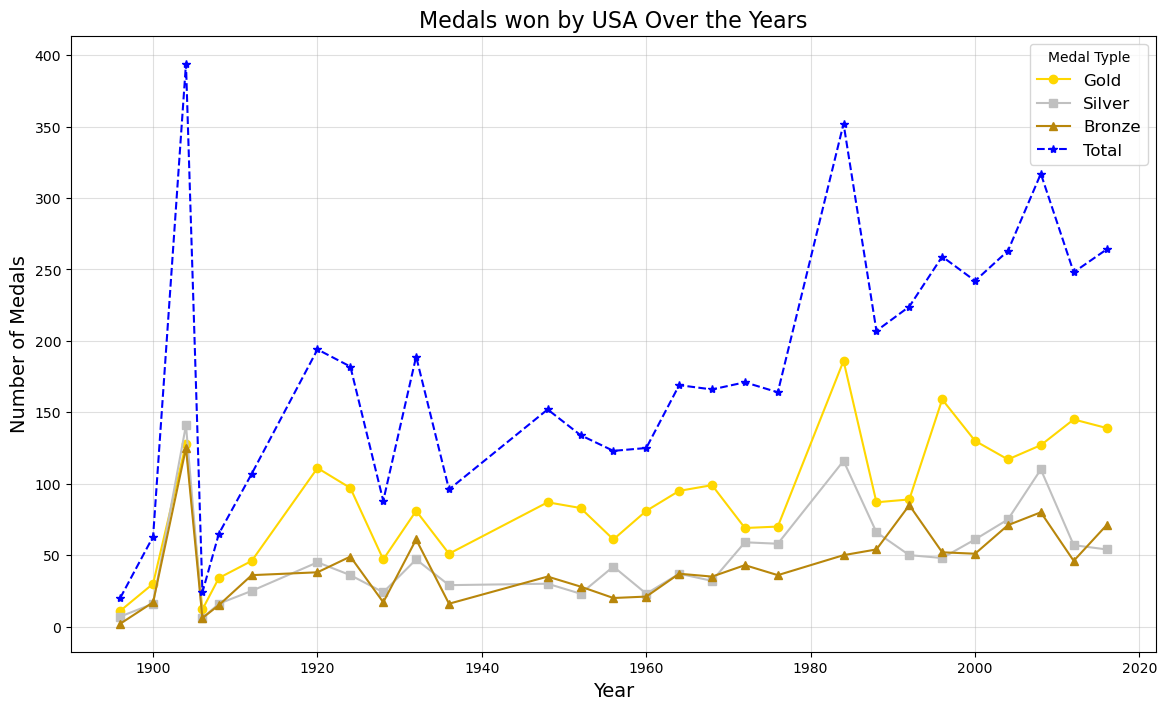

In [152]:
#Plots the chosen country's gold, silver, bronze and total medal count 
#throughout the years 

#filters rows with no Medals won out
medal_data = df_sum[df_sum['Medal'] != 'None']

#grouping by Year, Country/NOC, and medal to count medals
country_medals = (
    medal_data.groupby(['Year', 'NOC', 'Medal'])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)

#Add a Total column for the sum of all medals
country_medals['Total'] = country_medals['Gold'] + country_medals['Silver'] + country_medals['Bronze']

#function to create a line plot for a specific country
def plot_med_by_country():
    #getting user input
    country = input('Enter the 3-letter NOC code for the country of choice (ex. USA, CAN): ').upper()

    #filter data for the selected country
    country_data = country_medals[country_medals['NOC'] == country]

    #check if the country exists
    if country_data.empty:
        print(f"No data found for the country {country}. Please try again.")
        return

    #plot the data
    plt.figure(figsize=(14,8))
    plt.plot(country_data['Year'], country_data['Gold'], label = 'Gold', color='gold', marker='o')
    plt.plot(country_data['Year'], country_data['Silver'], label = 'Silver', color='silver', marker='s')
    plt.plot(country_data['Year'], country_data['Bronze'], label = 'Bronze', color='darkgoldenrod', marker='^')
    plt.plot(country_data['Year'], country_data['Total'], label = 'Total', color='blue', linestyle='--', marker='*')

    #adding labels, title, legend, and grid
    plt.title(f'Medals won by {country} Over the Years', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Number of Medals', fontsize=14)
    plt.legend(title='Medal Typle', fontsize=12)
    plt.grid(alpha=0.4)

    #show the plot
    plt.show()

plot_med_by_country()

Enter the 3-letter NOC code for the country of choice (ex. USA, CAN):  usa


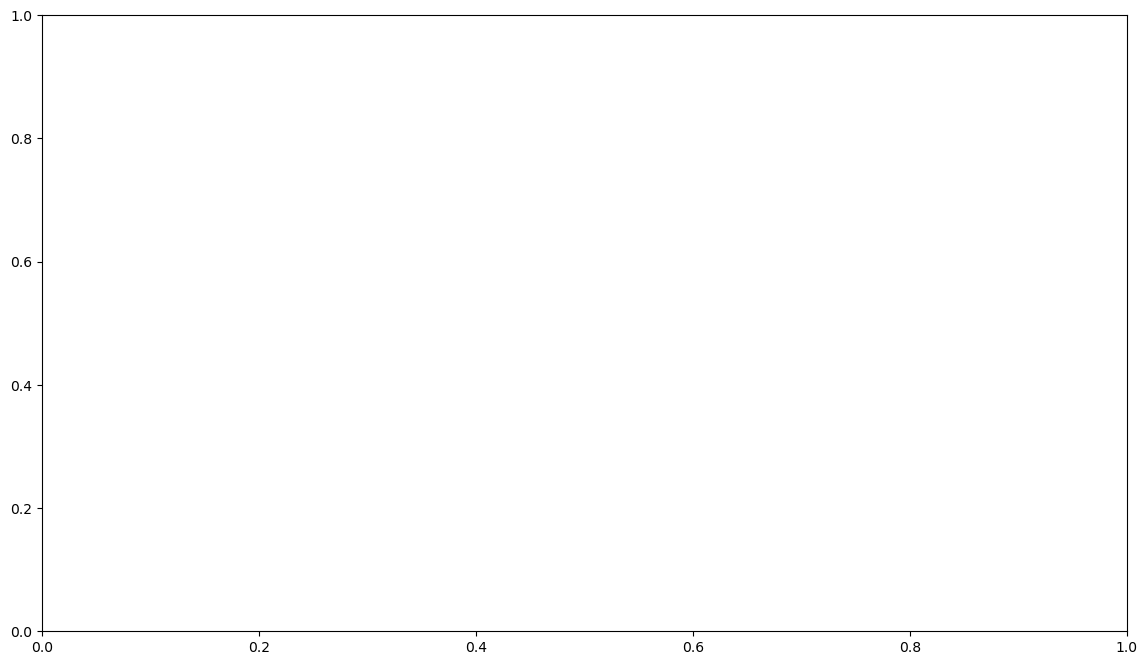

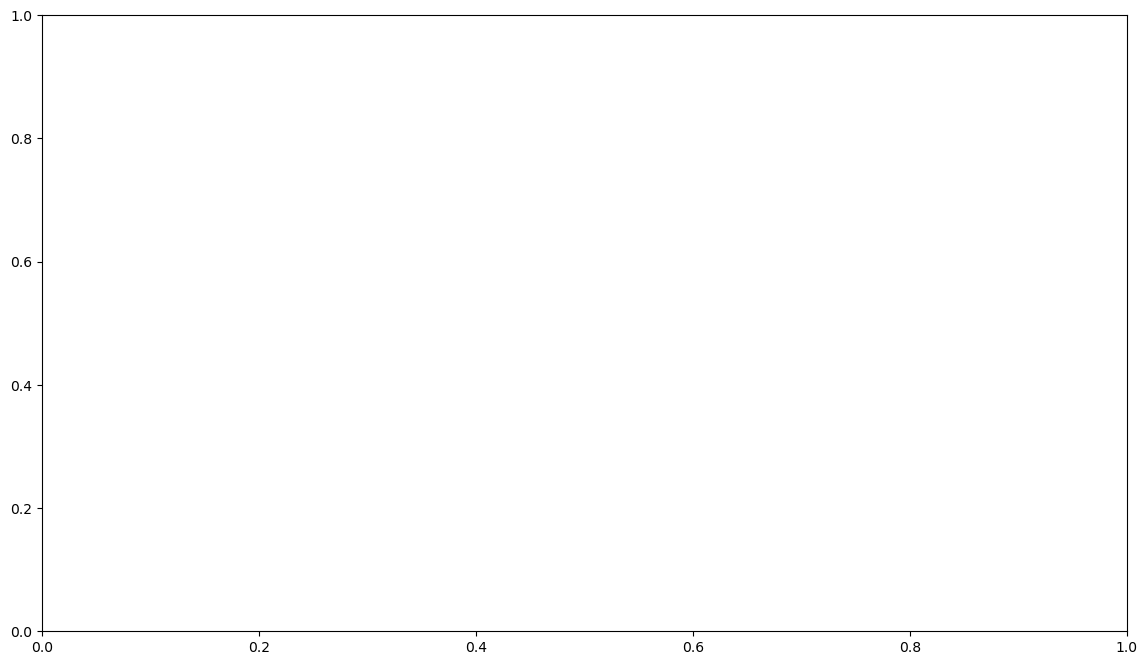

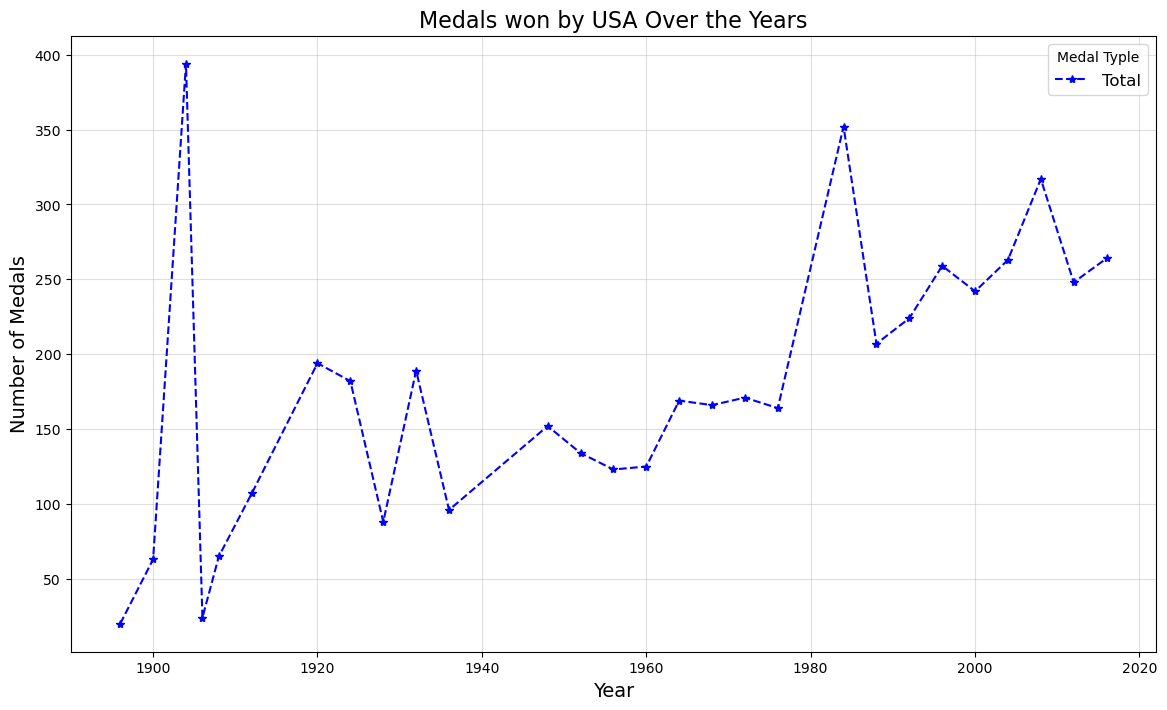

In [159]:
#plots just the total medal count for the chosen country 

#filters rows with no Medals won out
medal_data = df_sum[df_sum['Medal'] != 'None']

#grouping by Year, Country/NOC, and medal to count medals
country_medals = (
    medal_data.groupby(['Year', 'NOC', 'Medal'])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)

#Add a Total column for the sum of all medals
country_medals['Total'] = country_medals['Gold'] + country_medals['Silver'] + country_medals['Bronze']

#function to create a line plot for a specific country
def plot_med_by_country():
    #getting user input
    country = input('Enter the 3-letter NOC code for the country of choice (ex. USA, CAN): ').upper()

    #filter data for the selected country
    country_data = country_medals[country_medals['NOC'] == country]

    #check if the country exists
    if country_data.empty:
        print(f"No data found for the country {country}. Please try again.")
        return

    plt.figure(figsize=(14,8))
    plt.plot(country_data['Year'], country_data['Total'], label='Total', color='blue', linestyle='--', marker='*')
    
    #adding labels, title, legend, and grid
    plt.title(f'Medals won by {country} Over the Years', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Number of Medals', fontsize=14)
    plt.legend(title='Medal Typle', fontsize=12)
    plt.grid(alpha=0.4)

    plt.show()

plot_med_by_country()

Enter the 3-letter NOC code for the country of choice (ex. USA, CAN):  usa


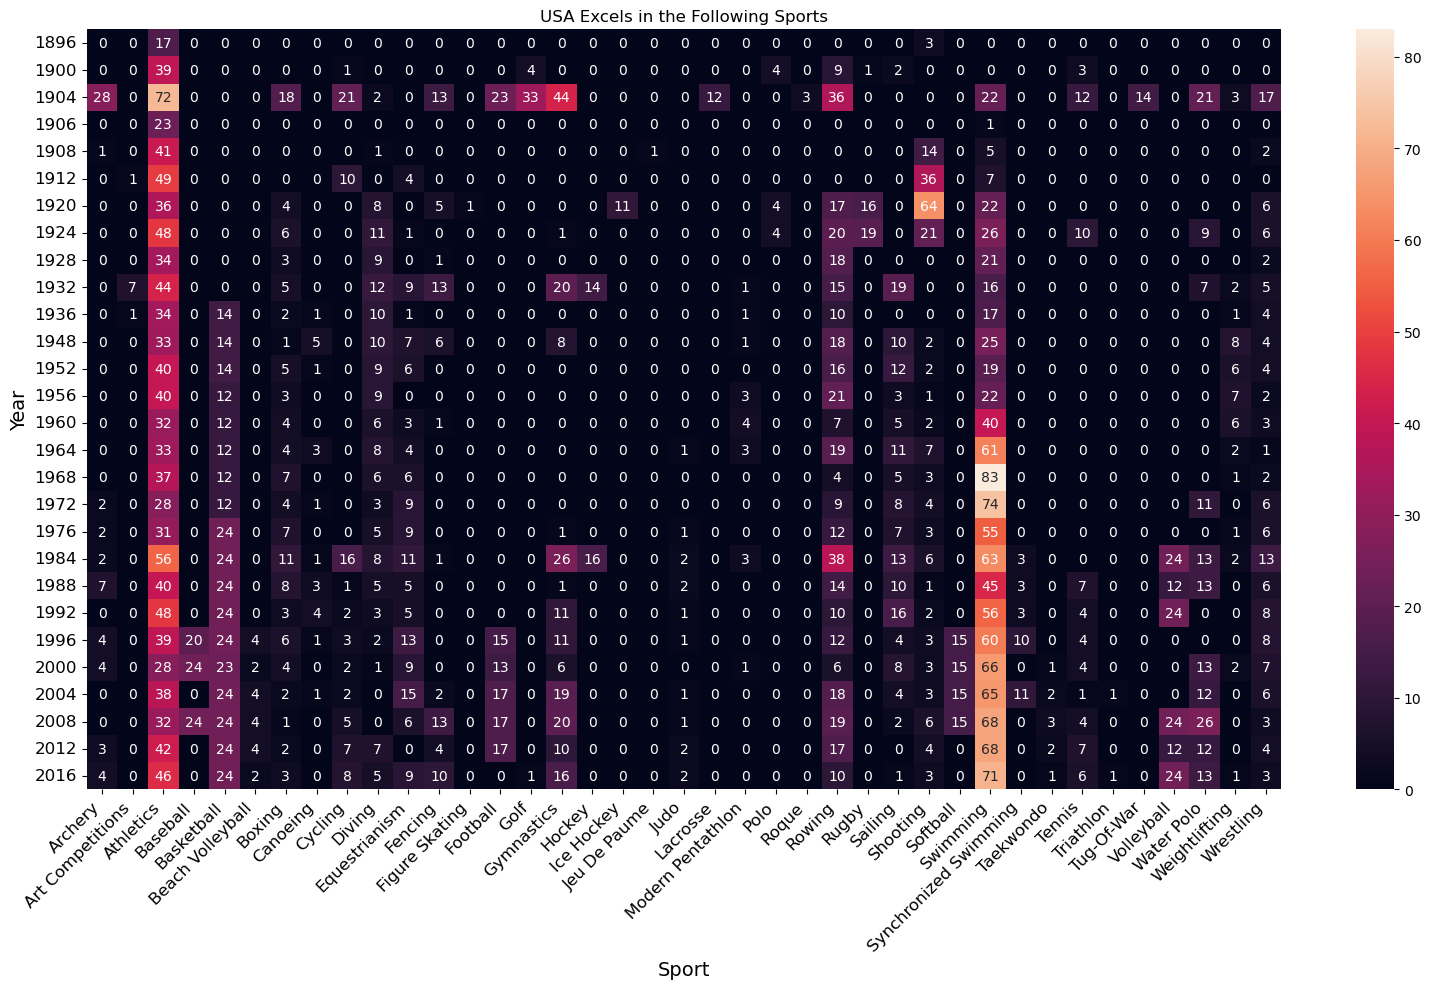

In [181]:
#Heatmap for number of events for each sport/event by country

#function to generate a heatmap for a user-selected country
def event_hm_by_country():
    
    #getting user input
    country = input('Enter the 3-letter NOC code for the country of choice (ex. USA, CAN): ').upper()

    #drops rows if medal is none
    medal_data = df_sum[df_sum['Medal'] != 'None']
    
    #filter data for the selected country
    country_data = medal_data[medal_data['NOC'] == country]

    #check if the country exists
    if country_data.empty:
        print(f"No data found for the country {country}. Please try again.")
        return

    #group data by sport and year to count the number of events
    event_count = (
        country_data.groupby(['Year', 'Sport'])
        .size()
        .unstack(fill_value=0)
    )

    #creates the heatmap
    plt.figure(figsize=(16,10))
    sns.heatmap(event_count, annot=True, fmt='d')

    #Add titles and labels
    plt.title(f'{country} Excels in the Following Sports')
    plt.xlabel('Sport', fontsize=14)
    plt.ylabel('Year', fontsize=14)

    #rotate sport names for better readability
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    #show the heatmap
    plt.tight_layout()
    plt.show()

#calls the function
event_hm_by_country()


In [221]:
#top 10 athletes by user chosen country

#function to get the top 10 athletes by country
def top_10_ath_cntry():
    #getting user input
    country = input('Enter the 3-letter NOC code for the country of choice (ex. USA, CAN): ').upper()

    #drops rows if medal is none
    medal_data = df_sum[df_sum['Medal'] != 'None']
    
    #filter data for the selected country
    country_data = medal_data[medal_data['NOC'] == country]

    #check if the country exists
    if country_data.empty:
        print(f"No data found for the country {country}. Please try again.")
        return

    #group by athletes and count their medals
    top_athletes = (
        country_data.groupby(['Name', 'Sport'])['Medal']
        .count()
        .reset_index()
        .sort_values(by='Medal', ascending= False)
    )

    #get top 10 athletes
    top_10 = top_athletes.head(10)

    #Displays the top 10 athletes
    print(f'Top 10 Athletes from {country} by Medals Won: ')
    print(top_10)

#call function
top_10_ath_cntry()

Enter the 3-letter NOC code for the country of choice (ex. USA, CAN):  usa


Top 10 Athletes from USA by Medals Won: 
                                                 Name      Sport  Medal
2339                          Michael Fred Phelps, II   Swimming     28
1532  Jennifer Elisabeth "Jenny" Thompson (-Cumpelik)   Swimming     12
646              Dara Grace Torres (-Hoffman, -Minas)   Swimming     12
2425                    Natalie Anne Coughlin (-Hall)   Swimming     12
2851                               Ryan Steven Lochte   Swimming     12
2196                                Mark Andrew Spitz   Swimming     11
2259                   Matthew Nicholas "Matt" Biondi   Swimming     11
351                              Carl Townsend Osburn   Shooting     11
1049                   Frederick Carlton "Carl" Lewis  Athletics     10
2634                      Raymond Clarence "Ray" Ewry  Athletics     10


### Athlete Analysis

/var/folders/yp/qgkt59n91fd4qcnpqq83ntlc0000gn/T/ipykernel_79935/2878243756.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Medal Type', fontsize=12)


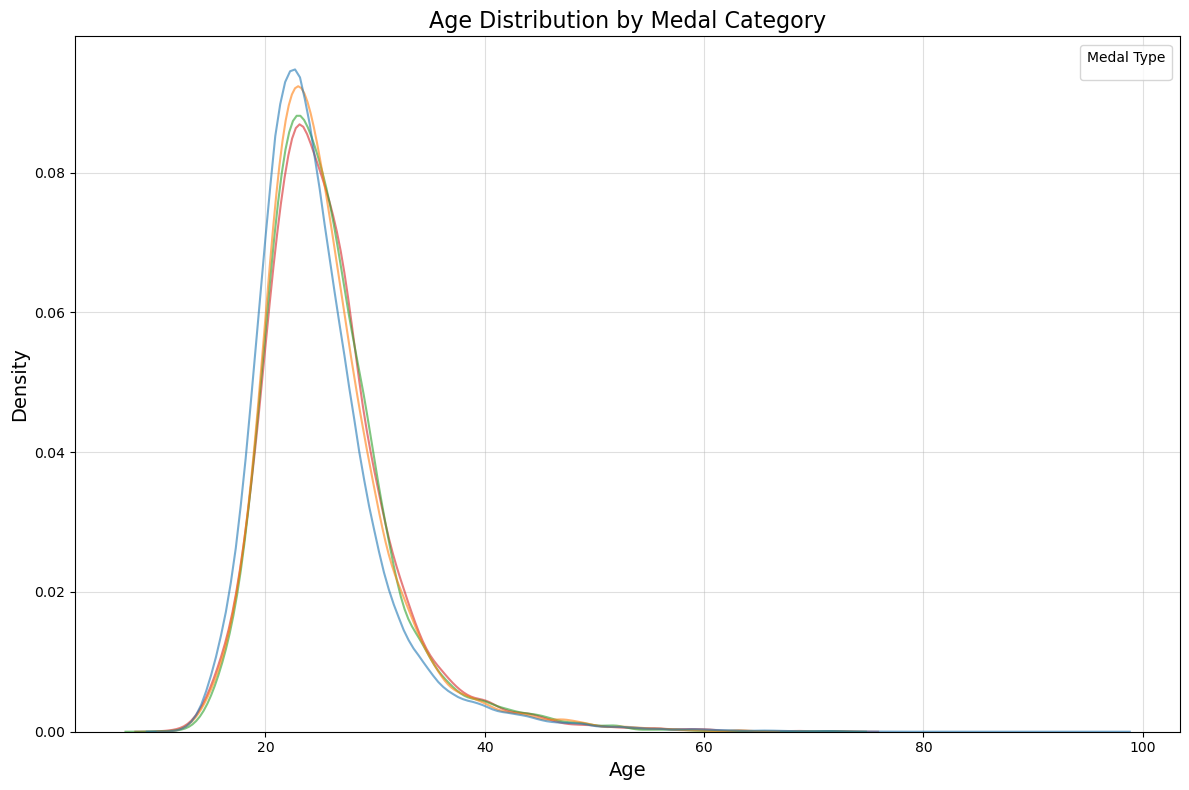

In [193]:
#Distribution of Age

#Drop duplicates and NaN in the Age column
def age_dist_medal():
    #drop rows with NaN in the Age column
    clean_data = df_sum.dropna(subset=['Age', 'Medal'])

    #Drop duplicate athletes for each medal category
    clean_data = clean_data.drop_duplicates(subset=['Name', 'Medal'])

    #create the distribution plot
    plt.figure(figsize=(12,8))
    sns.kdeplot(data=clean_data, x='Age', hue='Medal', fill=False, common_norm=False, alpha =0.6)

    #Add titles and labels
    plt.title("Age Distribution by Medal Category", fontsize=16)
    plt.xlabel('Age', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend(title='Medal Type', fontsize=12)
    plt.grid(alpha=0.4)
    
    #show the plot
    plt.tight_layout()
    plt.show()

#call function
age_dist_medal()

/var/folders/yp/qgkt59n91fd4qcnpqq83ntlc0000gn/T/ipykernel_79935/2616860177.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=gold_medals, x='Age', hue='Sport', fill=False, common_norm=False, alpha =0.7, linewidth=2)
/var/folders/yp/qgkt59n91fd4qcnpqq83ntlc0000gn/T/ipykernel_79935/2616860177.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Sport', bbox_to_anchor=(1.05, 1), loc='upper left')


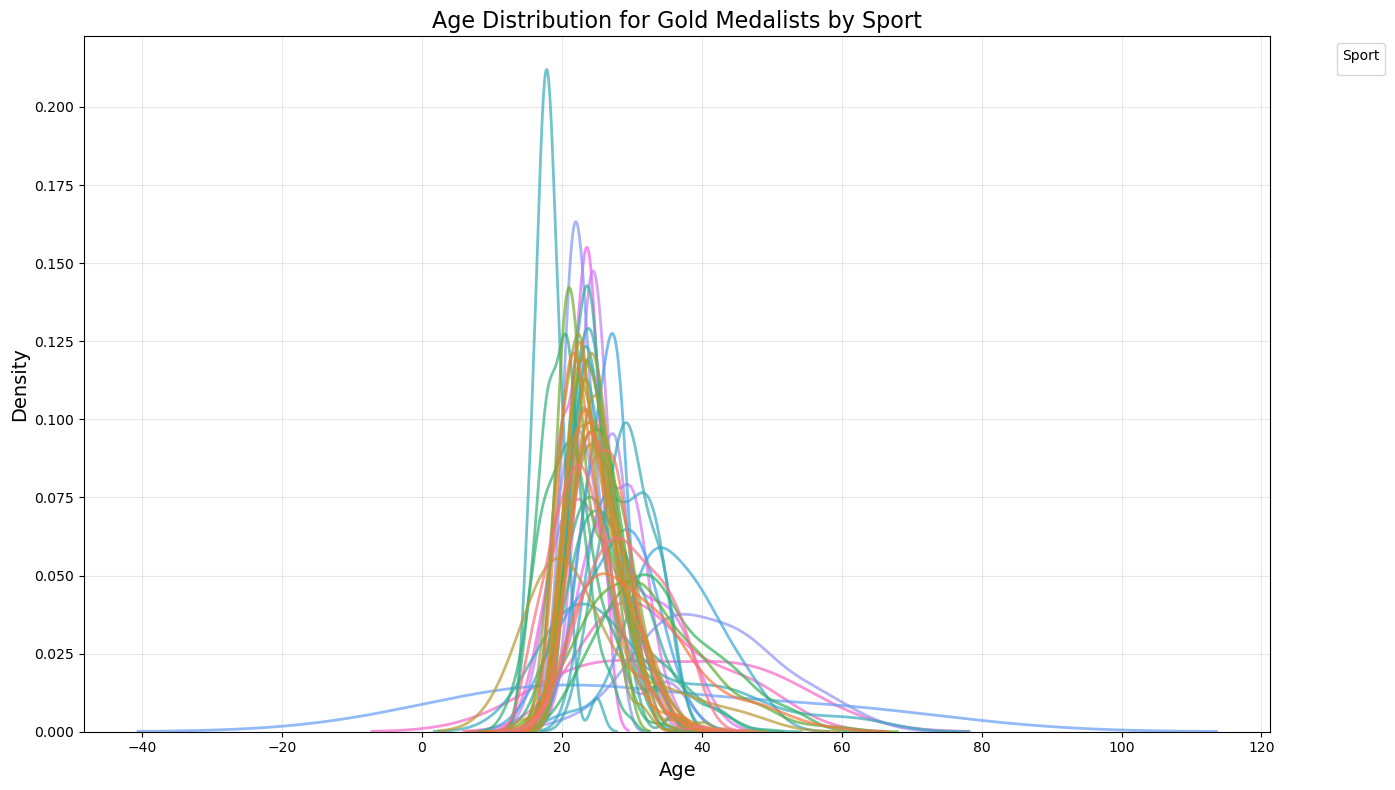

In [201]:
#Look at the Age Distribution for all sports for Gold medalists
#Drop duplicates and NaN in the Age column
def age_dist_medal_sport():
    #filters data for gold medalists only
    gold_medals = df_sum[(df_sum['Medal'] == 'Gold')]
    
    #drop rows with NaN in the Age column
    gold_medals = gold_medals.dropna(subset=['Age'])

    #Drop duplicate athletes for each medal category
    gold_medals = gold_medals.drop_duplicates(subset=['Name', 'Sport'])

    #create the distribution plot
    plt.figure(figsize=(14,8))
    sns.kdeplot(data=gold_medals, x='Age', hue='Sport', fill=False, common_norm=False, alpha =0.7, linewidth=2)

    #Add titles and labels
    plt.title("Age Distribution for Gold Medalists by Sport", fontsize=16)
    plt.xlabel('Age', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend(title='Sport', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    
    #show the plot
    plt.tight_layout()
    plt.show()

#call function
age_dist_medal_sport()

Enter the sport to analyze (ex. swimming, basketball, etc):  Basketball


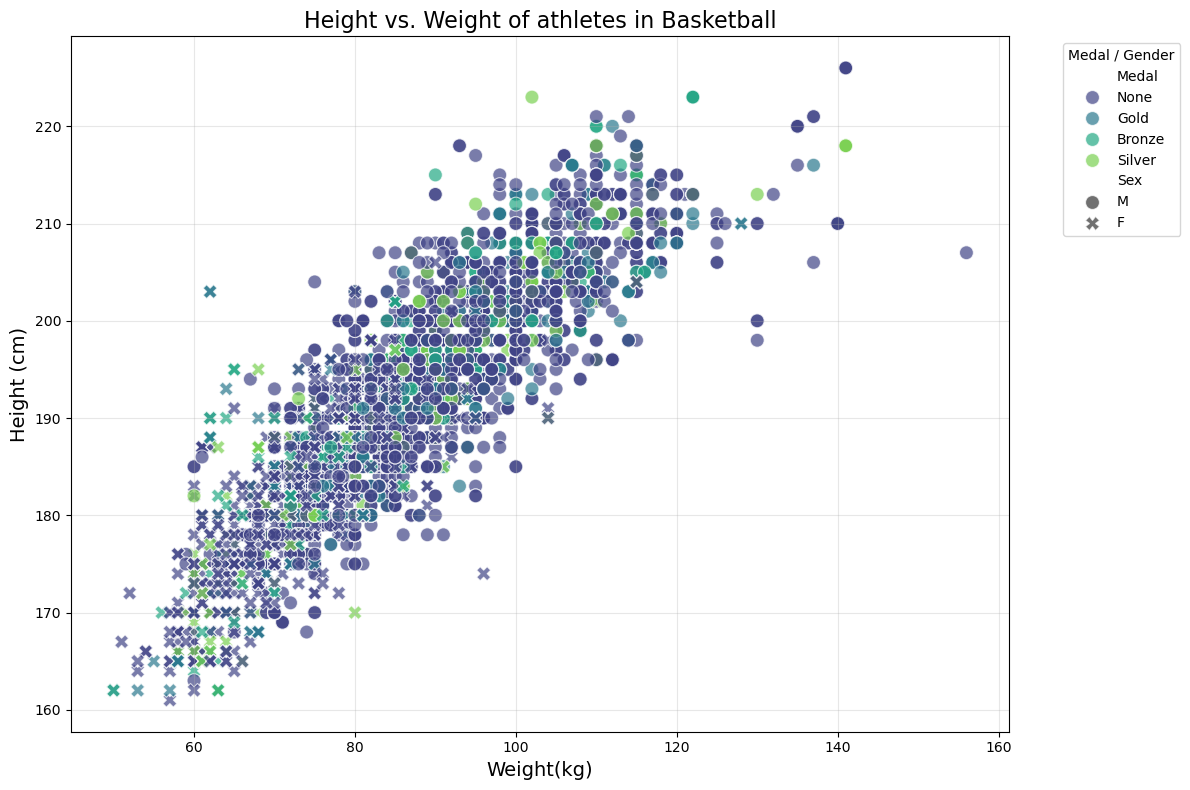

In [211]:
#comparing the height vs. weight of user selected sports
#looks at medal won and gender

#function to create scatter plot
def height_v_weight():
    #getting user sport input
    sport = input('Enter the sport to analyze (ex. swimming, basketball, etc): ')

    #filter data based off chosen sport
    sport_data = df_sum[df_sum['Sport'] == sport]

    #handles missing values in height/weight and medal columns
    sport_data = sport_data.dropna(subset=['Height', 'Weight'])

    #fill missing medals with No Medal
    sport_data['Medal'] = sport_data['Medal'].fillna('None')

    plt.figure(figsize=(12,8))
    sns.scatterplot(data=sport_data, x='Weight', y='Height', hue='Medal', style='Sex', palette ='viridis', alpha=0.7, s=100)

    #title and labels
    plt.title(f'Height vs. Weight of athletes in {sport}', fontsize=16)
    plt.xlabel('Weight(kg)', fontsize=14)
    plt.ylabel('Height (cm)', fontsize=14)
    plt.legend(title='Medal / Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)

    #show plot
    plt.tight_layout()
    plt.show()

#call function
height_v_weight()

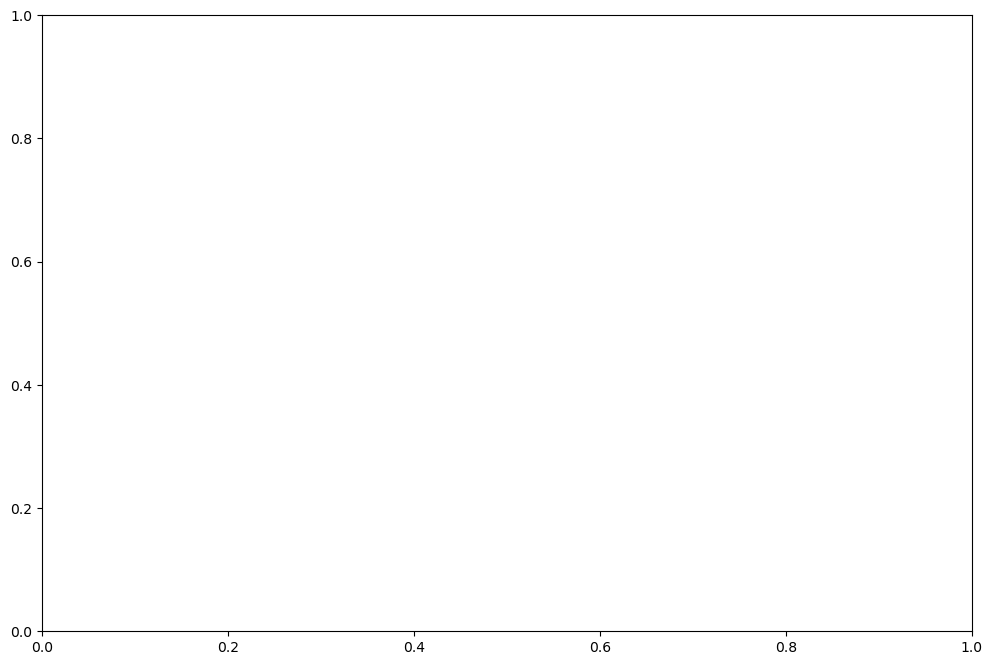

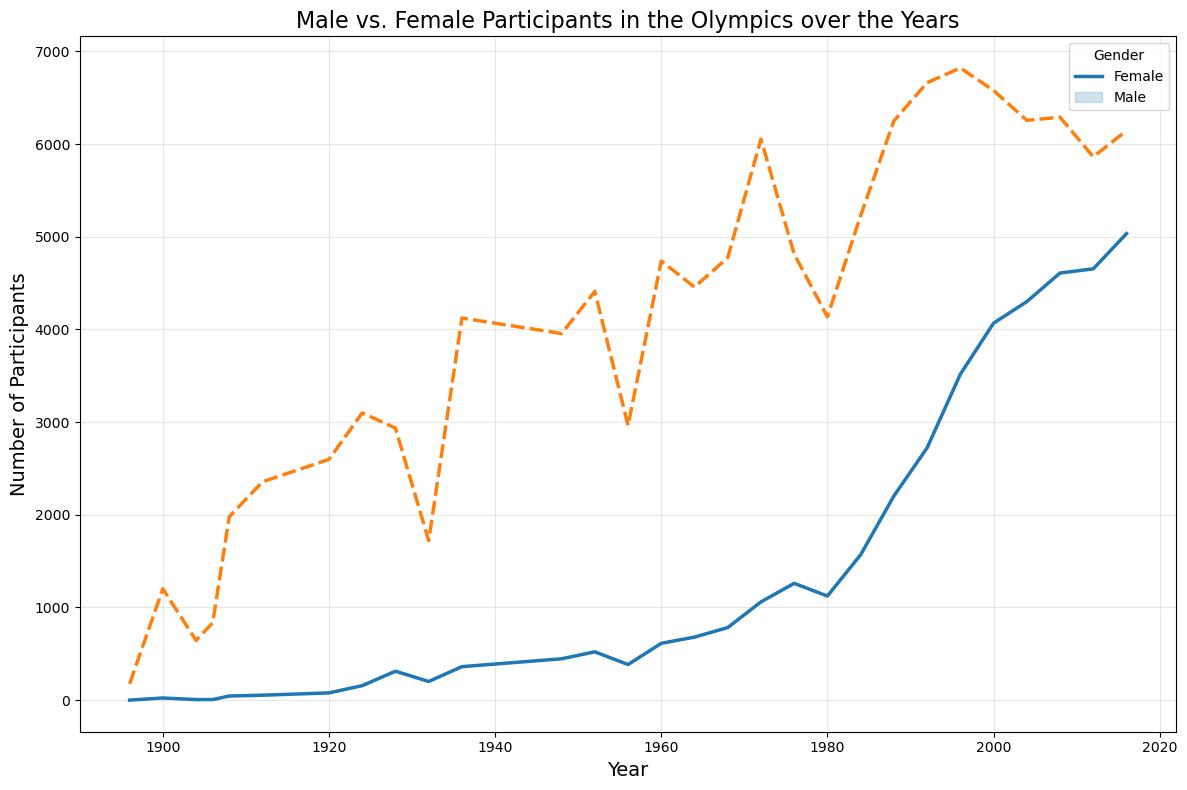

In [215]:
#comparing the male vs. female participation throughout the years

#function to create the line plot of male v. female over the years
def men_v_women():
    #group data by year and sex, then count the number of participants
    gender_count = df_sum.groupby(['Year', 'Sex'])['ID'].nunique().reset_index()

    #pivot data to have separate columns for male and female
    gender_count_pivot = gender_count.pivot(index='Year', columns='Sex', values='ID').fillna(0)

    #rename columns for clarity
    gender_count_pivot.columns = ['Female', 'Male']

    #plot data
    plt.figure(figsize=(12,8))
    sns.lineplot(data=gender_count_pivot, linewidth=2.5)

    #add titles and labels
    plt.title('Male vs. Female Participants in the Olympics over the Years', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Number of Participants', fontsize=14)
    plt.legend(title='Gender', labels=['Female', 'Male'])
    plt.grid(alpha=0.3)

    #show plot
    plt.tight_layout()
    plt.show()

#call function
men_v_women()